In [1]:
%pylab inline
import seaborn as sns
from matplotlib.lines import Line2D


# Local
import plotting
import global_imports
c = global_imports._c
G = global_imports._G
Msun = global_imports._M_s
pi = global_imports._pi
rho_ns = global_imports._rhons


c_dark_energy = plotting.c_dark_energy
c_bosonic = plotting.c_bosonic
c_fermionic= plotting.c_fermionic
c_baryonic = plotting.c_baryonic

Populating the interactive namespace from numpy and matplotlib


In [2]:
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)

pyplot.rc('text', usetex=True)
pyplot.rc('font', family='serif')

pyplot.rcParams['xtick.direction'] = 'in'
pyplot.rcParams['xtick.minor.visible'] = True
pyplot.rcParams['ytick.direction'] = 'in'
pyplot.rcParams['ytick.minor.visible'] = True
pyplot.rcParams['xtick.major.size'] = 5
pyplot.rcParams['ytick.major.size'] = 5
pyplot.rcParams['ytick.right'] = True
pyplot.rcParams['xtick.top'] = True

In [3]:
def stacking(y, x):
    return np.hstack((y.reshape(-1,1), x.reshape(-1,1)))
    
plot = plotting.plot_KDE

In [4]:
#Dark energy 
run_name = 'DE/Dark_energy_posterior_'
Dark_energy_table_data = np.loadtxt(run_name + 'table_data.txt') # M_TOV, R_TOV, R_2, R_1.4
Dark_energy_mtov = Dark_energy_table_data[:,0]
Dark_energy_r14 =Dark_energy_table_data[:,2]
Dark_energy_r2 = Dark_energy_table_data[:,3]
Dark_energy_deltar = Dark_energy_r2 - Dark_energy_r14
#Bosonic 
run_name = 'BDM/Bosonic_posterior_'
Bosonic_table_data = np.loadtxt(run_name + 'table_data.txt')
Bosonic_mtov = Bosonic_table_data[:,0]
Bosonic_r14 =Bosonic_table_data[:,2]
Bosonic_r2 = Bosonic_table_data[:,3]
Bosonic_deltar = Bosonic_r2 - Bosonic_r14

#Fermionic
run_name = 'FDM/Fermionic_posterior_'
Fermionic_table_data = np.loadtxt(run_name + 'table_data.txt')
Fermionic_mtov = Fermionic_table_data[:,0]
Fermionic_r14 =Fermionic_table_data[:,2]
Fermionic_r2 = Fermionic_table_data[:,3]
Fermionic_deltar = Fermionic_r2 - Fermionic_r14

#Baryonic
run_name = 'B/Baryonic_posterior_'
Baryonic_table_data = np.loadtxt(run_name + 'table_data.txt') #full table data: M_TOV, R_TOV, eps_cent_TOV, rho_cent_TOV, P_cent_TOV, R_1.4,
                                                     #eps_cent_1.4, rho_cent_1.4, P_cent_1.4, R_2.0, eps_cent_2.0, rho_cent_2.0, P_cent_2.0.
#Baryonic_table_data = Baryonic_table_data[:,[0,1,5,9]]

Baryonic_mtov = Baryonic_table_data[:,0]
Baryonic_r14 =Baryonic_table_data[:,2]
Baryonic_r2 = Baryonic_table_data[:,3]
Baryonic_deltar = Baryonic_r2 - Baryonic_r14

In [5]:
def get_quantiles(array, quantiles=[0.025, 0.5, 0.975]):
        contours = np.nanquantile(array, quantiles) #changed to nanquantile to inorder to ignore the nans that may appear
        low = contours[0]
        median = contours[1]
        high = contours[2]
        minus = low - median
        plus = high - median
        return np.round(median,2),np.round(plus,2),np.round(minus,2)  #returns uncertainties on the array

In [6]:
print('Baryonic Only')
Data_array = Baryonic_table_data
print('M_TOV: ', get_quantiles(Data_array[:,0]))
print('R_TOV: ', get_quantiles(Data_array[:,1]))
print('R_1.4: ', get_quantiles(Data_array[:,2]))
print('R_2.0: ', get_quantiles(Data_array[:,3]))
print('Delta R = R_2.0 - R_1.4: ', get_quantiles(Data_array[:,3] - Data_array[:,2]))

Baryonic Only
M_TOV:  (2.16, 0.14, -0.15)
R_TOV:  (12.14, 1.08, -1.46)
R_1.4:  (12.26, 0.65, -0.62)
R_2.0:  (12.27, 0.92, -1.19)
Delta R = R_2.0 - R_1.4:  (0.02, 0.33, -0.74)


In [7]:
print('Dark Energy')
Data_array = Dark_energy_table_data
print('M_TOV: ', get_quantiles(Data_array[:,0]))
print('R_TOV: ', get_quantiles(Data_array[:,1]))
print('R_1.4: ', get_quantiles(Data_array[:,2]))
print('R_2.0: ', get_quantiles(Data_array[:,3]))
print('Delta R = R_2.0 - R_1.4: ', get_quantiles(Data_array[:,3] - Data_array[:,2]))

Dark Energy
M_TOV:  (2.29, 0.45, -0.3)
R_TOV:  (11.67, 1.37, -1.08)
R_1.4:  (11.74, 0.92, -0.82)
R_2.0:  (12.13, 1.1, -1.06)
Delta R = R_2.0 - R_1.4:  (0.45, 0.43, -0.84)


In [8]:
print('Fermionic ADM')
Data_array = Fermionic_table_data
print('M_TOV: ', get_quantiles(Data_array[:,0]))
print('R_TOV: ', get_quantiles(Data_array[:,1]))
print('R_1.4: ', get_quantiles(Data_array[:,2]))
print('R_2.0: ', get_quantiles(Data_array[:,3]))
print('Delta R = R_2.0 - R_1.4: ', get_quantiles(Data_array[:,3] - Data_array[:,2]))

Fermionic ADM
M_TOV:  (2.12, 0.16, -0.14)
R_TOV:  (11.95, 1.08, -1.25)
R_1.4:  (12.16, 0.64, -0.61)
R_2.0:  (12.09, 0.93, -1.05)
Delta R = R_2.0 - R_1.4:  (-0.07, 0.37, -0.68)


In [9]:
print('Bosonic ADM')
Data_array = Bosonic_table_data
print('M_TOV: ', get_quantiles(Data_array[:,0]))
print('R_TOV: ', get_quantiles(Data_array[:,1]))
print('R_1.4: ', get_quantiles(Data_array[:,2]))
print('R_2.0: ', get_quantiles(Data_array[:,3]))
print('Delta R = R_2.0 - R_1.4: ', get_quantiles(Data_array[:,3] - Data_array[:,2]))

Bosonic ADM
M_TOV:  (2.12, 0.16, -0.14)
R_TOV:  (11.97, 1.08, -1.25)
R_1.4:  (12.16, 0.64, -0.62)
R_2.0:  (12.1, 0.94, -1.06)
Delta R = R_2.0 - R_1.4:  (-0.05, 0.36, -0.67)


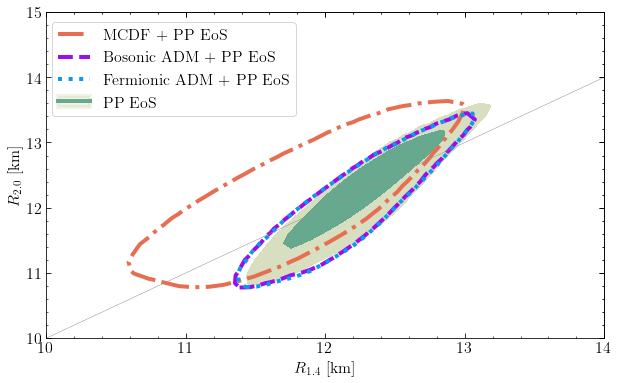

In [10]:
width = 10
height = 6

fig, axes = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(width,height))
# fig.subplots_adjust(wspace=0, hspace=0)

# Set axis limits and ticks
r_min = 10
r_max = 14
r14_min = r_min
r14_max = r_max
r2_min = r_min
r2_max = 15
ticks = [10,11,12,13,14]
xlabel = '$R_{1.4}$ [km]'
ylabel = '$R_{2.0}$ [km]'
axes.set_xlabel(xlabel,fontsize = 16)
# axes[1,1].set_xlabel(xlabel)
axes.set_ylabel(ylabel,fontsize = 16)
# axes[1,0].set_ylabel(ylabel)
# axes[0,0].set_title('PP')
# axes[0,1].set_title('CS')

axes.minorticks_on()

axes.set_xlim(r14_min,r14_max) 
axes.set_ylim(r2_min,r2_max) 
axes.set_xticks(ticks) 
axes.set_xticklabels(ticks, fontsize = 16)
ticks = [10,11,12,13,14,15]
axes.set_yticks(ticks) 
axes.set_yticklabels(ticks,fontsize = 16)

plotting.top_side_ticks(axes)
plotting.right_side_ticks(axes)

diagonal = np.linspace(r_min, r_max)

bw_adjust = 2.0 # bw_adjust taken to 2 because contours seemed jagged 



ax = axes
data = stacking(Dark_energy_r2, Dark_energy_r14)
plot(ax, data, c_dark_energy, False,[0.05, 1], '-.', bw_adjust=bw_adjust)

data = stacking(Bosonic_r2, Bosonic_r14)
plot(ax, data, c_bosonic, False, [0.05, 1], '--', bw_adjust=bw_adjust)

data = stacking(Fermionic_r2, Fermionic_r14)
plot(ax, data, c_fermionic, False, [0.05, 1], 'dotted', bw_adjust=bw_adjust)

data = stacking(Baryonic_r2, Baryonic_r14)
plot(ax, data, c_baryonic, True, bw_adjust=bw_adjust)

ax.plot(diagonal, diagonal, color='xkcd:gray', lw=0.5)

# Add text
# txt = "Chiral EFT $\leq 1.1 n_0$"
# ax = axes[0,0]
# ax.text(0.03, 0.90, txt, transform=ax.transAxes)
# txt = "Chiral EFT $\leq 1.5 n_0$"
# ax = axes[1,0]
# ax.text(0.03, 0.90, txt, transform=ax.transAxes)




# axes[1,0].set_zorder(1)
# axes[1,1].set_zorder(2)
# axes[0,0].set_zorder(3)
# axes[0,1].set_zorder(4)

# Add legends
line1 = plotting.custom_line(c_dark_energy, '-.',lw=4)
line2 = plotting.custom_line(c_bosonic, '--',lw=4)
line3 = plotting.custom_line(c_fermionic, 'dotted',lw=4)
line4 = plotting.double_interval_legend(c_baryonic)
custom_lines = [line1, line2, line3, line4]
labels = ['MCDF + PP EoS', 'Bosonic ADM + PP EoS', 'Fermionic ADM + PP EoS', 'PP EoS']
loc = (0.01,0.68)
axes.legend(custom_lines, labels, loc=loc, fontsize = 16, frameon=True)

fig.savefig('plots/R2_vs_R14.pdf', bbox_inches='tight')

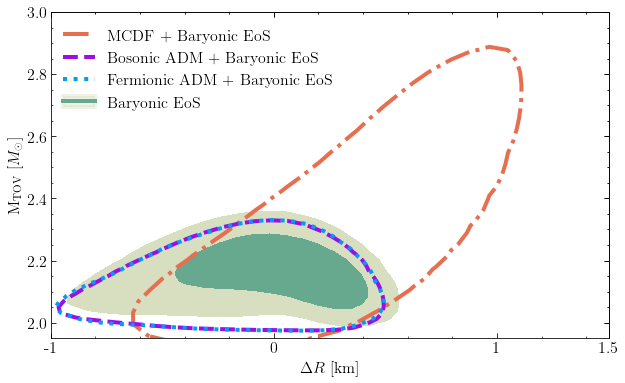

In [11]:
width = 10
height = 6

fig, axes = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(width,height))
# fig.subplots_adjust(wspace=0, hspace=0)

# Set axis limits and ticks
# Set axis limits and ticks
delta_R_min = -1.0
delta_R_max = 1.5
maxmass_min = 1.95
maxmass_max = 3.

xticks = [ -1, 0, 1,1.5]
xticklabels = ['$-1$', '$0$', '$1$','$1.5$']
yticks = [2.0, 2.2, 2.4, 2.6, 2.8,3.]

xlabel = r'$\Delta R$ [km]'
ylabel = r'M$_\mathrm{TOV}$ $[M_{\odot}]$'
axes.set_xlabel(xlabel,fontsize = 16)

# axes[1,1].set_xlabel(xlabel)
axes.set_ylabel(ylabel,fontsize = 16)
# axes[1,0].set_ylabel(ylabel)
# axes[0,0].set_title('PP')
# axes[0,1].set_title('CS')

axes.minorticks_on()


axes.set_xlim(delta_R_min,delta_R_max) 
axes.set_ylim(maxmass_min,maxmass_max) 
axes.set_xticks(xticks) 
axes.set_xticklabels(xticks, fontsize = 16)

axes.set_yticks(yticks) 
axes.set_yticklabels(yticks,fontsize = 16)

plotting.top_side_ticks(axes)
plotting.right_side_ticks(axes)



bw_adjust = 2.0 # bw_adjust taken to 2 because contours seemed jagged 



ax = axes
data = stacking(Dark_energy_mtov, Dark_energy_deltar)
plot(ax, data, c_dark_energy, False, [0.05, 1], '-.', bw_adjust=bw_adjust)

data = stacking(Bosonic_mtov, Bosonic_deltar)
plot(ax, data, c_bosonic, False,  [0.05, 1], '--', bw_adjust=bw_adjust)

data = stacking(Fermionic_mtov, Fermionic_deltar)
plot(ax, data, c_fermionic, False, [0.05, 1], 'dotted', bw_adjust=bw_adjust)

data = stacking(Baryonic_mtov, Baryonic_deltar)
plot(ax, data, c_baryonic, True, bw_adjust=bw_adjust)


line1 = plotting.custom_line(c_dark_energy, '-.',lw=4)
line2 = plotting.custom_line(c_bosonic, '--',lw=4)
line3 = plotting.custom_line(c_fermionic, 'dotted',lw=4)
line4 = plotting.double_interval_legend(c_baryonic)
custom_lines = [line1, line2, line3, line4]
labels = ['MCDF + Baryonic EoS', 'Bosonic ADM + Baryonic EoS', 'Fermionic ADM + Baryonic EoS', 'Baryonic EoS']
loc = (0.01,0.68)
axes.legend(custom_lines, labels, loc=loc, fontsize = 16, frameon=False)

fig.savefig('plots/MTOV_vs_DeltaR.pdf', bbox_inches='tight')